# Chapitre 5 — Processus de Décision Markovien (MDP)
## Modélisation Stochastique et Optimisation de la Sécurité des Réseaux Informatiques

**Module :** Apprentissage Probabiliste — Prof. Nizar Ben Kasmia  
**Dataset :** UNSW-NB15 — Network Intrusion Detection

---

### Plan
1. Introduction — Exemples Introductifs
2. Définition Informelle & Formelle du MDP
3. Construction du MDP depuis UNSW-NB15
4. Politique Stationnaire — **Algorithme de Howard**
5. **Coûts Actualisés** — Facteur γ (horizon infini)
6. **Horizons Temporels** : Fini vs Infini
7. **Fonction de Valeur** V(s)
8. **Fonction de Valeur État-Action** Q(s,a)
9. **Value Iteration** (Bellman)
10. Comparaison Howard vs Value Iteration
11. Visualisations complètes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('=' * 70)
print('  CHAPITRE 5 — Processus de Décision Markovien (MDP)')
print('  Dataset : UNSW-NB15 | Sécurité des Réseaux Informatiques')
print('=' * 70)


  CHAPITRE 5 — Processus de Décision Markovien (MDP)
  Dataset : UNSW-NB15 | Sécurité des Réseaux Informatiques


---
## PARTIE 0 — Chargement du Dataset UNSW-NB15


In [2]:
# ============================================================
# CHARGEMENT UNSW-NB15
# ============================================================
TRAIN_PATH = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv'
TEST_PATH  = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_testing-set.csv'

FEATURES = ['dur','sbytes','dbytes','rate','sttl','dttl',
            'sload','dload','spkts','dpkts','smean','dmean',
            'ct_state_ttl','ct_dst_ltm','ct_src_ltm']
TARGET = 'label'

def load_and_clean(path, features, target):
    df = pd.read_csv(path)
    cols = [f for f in features if f in df.columns]
    d = df[cols + [target, 'attack_cat']].copy()
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    d.fillna(d.median(numeric_only=True), inplace=True)
    return d, cols

try:
    df_train, feats = load_and_clean(TRAIN_PATH, FEATURES, TARGET)
    df_test,  _     = load_and_clean(TEST_PATH,  FEATURES, TARGET)
    print(f'✅ UNSW-NB15 chargé — Train: {df_train.shape}  |  Test: {df_test.shape}')
except Exception as e:
    print(f'⚠️  Dataset non trouvé ({e})')
    print('   → Simulation réaliste UNSW-NB15...')

    def simulate_unsw(n=82000):
        rng = np.random.default_rng(42)
        cats = (['Normal']*45000+['Fuzzers']*12000+['Analysis']*4000+
                ['Backdoors']*2000+['DoS']*5000+['Exploits']*11000+
                ['Reconnaissance']*2000+['Shellcode']*700+['Worms']*300)
        rng.shuffle(cats); cats = cats[:n]
        rows = []
        for cat in cats:
            lbl = 0 if cat=='Normal' else 1
            p = {'Normal':[2,5000,3000,50],'Fuzzers':[0.5,2000,1000,200],
                 'Analysis':[1,3000,2000,100],'Backdoors':[5,8000,7000,20],
                 'DoS':[0.1,50000,100,5000],'Exploits':[3,6000,5000,80],
                 'Reconnaissance':[0.3,1000,500,300],'Shellcode':[2,4000,4000,60],
                 'Worms':[8,9000,8000,10]}.get(cat,[1,1000,1000,100])
            d=rng.exponential(p[0]); sb=rng.exponential(p[1]); db=rng.exponential(p[2])
            rt=rng.exponential(p[3])
            rows.append({'dur':d,'sbytes':sb,'dbytes':db,'rate':rt,
                         'sttl':rng.integers(50,130),'dttl':rng.integers(50,130),
                         'sload':sb/max(d,1e-6),'dload':db/max(d,1e-6),
                         'spkts':max(1,int(rt*d)),'dpkts':max(1,int(rt*d*0.8)),
                         'smean':max(1,sb/max(int(rt*d),1)),
                         'dmean':max(1,db/max(int(rt*d*0.8),1)),
                         'ct_state_ttl':rng.integers(0,6),
                         'ct_dst_ltm':rng.integers(0,50),
                         'ct_src_ltm':rng.integers(0,50),
                         'label':lbl,'attack_cat':cat})
        return pd.DataFrame(rows)

    full = simulate_unsw(82000)
    df_train = full.iloc[:60000].copy()
    df_test  = full.iloc[60000:].copy()
    feats = FEATURES
    print(f'✅ Simulation OK — Train: {df_train.shape}  |  Test: {df_test.shape}')

scaler  = StandardScaler()
X_train = scaler.fit_transform(df_train[feats])
X_test  = scaler.transform(df_test[feats])
y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

print(f'\nDistribution des attaques (train) :')
for cat, cnt in df_train['attack_cat'].value_counts().items():
    print(f'  {cat:20s}: {cnt:6d}  ({cnt/len(df_train)*100:.1f}%)')


✅ UNSW-NB15 chargé — Train: (175341, 17)  |  Test: (82332, 17)

Distribution des attaques (train) :
  Normal              :  56000  (31.9%)
  Generic             :  40000  (22.8%)
  Exploits            :  33393  (19.0%)
  Fuzzers             :  18184  (10.4%)
  DoS                 :  12264  (7.0%)
  Reconnaissance      :  10491  (6.0%)
  Analysis            :   2000  (1.1%)
  Backdoor            :   1746  (1.0%)
  Shellcode           :   1133  (0.6%)
  Worms               :    130  (0.1%)


---
## PARTIE 1 — Introduction et Exemples Introductifs

### Pourquoi un MDP pour la cybersécurité ?

Un système de défense réseau doit prendre des **décisions séquentielles** face à des menaces incertaines :
- L'état du réseau **évolue de façon stochastique** (une connexion normale peut devenir suspecte)
- Chaque décision (autoriser/alerter/bloquer) a un **coût immédiat** ET des **conséquences futures**
- L'objectif est de trouver la **politique optimale** à long terme

### Exemple introductif

| Situation | Chapitre 1-4 | Chapitre 5 (MDP) |
|---|---|---|
| Modèle | DTMC / CTMC / HMM | MDP |
| Agent | Passif (observe) | **Actif** (décide) |
| Objectif | Prédire l'état | **Maximiser la récompense** |
| Exemple | P(attaque à t+1) | Quelle action prendre en état s ? |

### Lien DTMC → MDP
Un MDP est une **DTMC contrôlée** : la matrice de transition $P(s'|s,a)$ dépend de l'action $a$ choisie par l'agent.


In [3]:
# ============================================================
# EXEMPLE INTRODUCTIF — MDP simple 2 états (illustration)
# ============================================================
print('=' * 70)
print('EXEMPLE INTRODUCTIF — MDP 2 états (Normal / Attaque)')
print('=' * 70)
print("""
  États cachés  : S = {Normal, Attaque}
  Actions       : A = {Autoriser, Bloquer}
  Récompenses   :
    R(Normal,  Autoriser) = +10   (trafic légitime autorisé)
    R(Normal,  Bloquer)   = -20   (faux positif : service interrompu)
    R(Attaque, Autoriser) = -100  (faux négatif : attaque non détectée)
    R(Attaque, Bloquer)   = +50   (attaque bloquée avec succès)

  Transitions P(s'|s, Autoriser) :
    P(Normal  | Normal,  Autoriser) = 0.95
    P(Attaque | Normal,  Autoriser) = 0.05
    P(Normal  | Attaque, Autoriser) = 0.10
    P(Attaque | Attaque, Autoriser) = 0.90

  → L'objectif : trouver π*(s) = argmax_a E[Σ γᵗ R(sₜ,aₜ)]
""")

# Illustration numérique
P_ex = np.array([[[0.95, 0.05],   # Autoriser depuis Normal
                  [0.10, 0.90]],  # Autoriser depuis Attaque
                 [[0.99, 0.01],   # Bloquer depuis Normal
                  [0.70, 0.30]]]) # Bloquer depuis Attaque
R_ex = np.array([[10, -20],    # Normal : [Autoriser, Bloquer]
                 [-100, 50]])  # Attaque : [Autoriser, Bloquer]

print('  Matrice de récompense R(s,a) :')
df_ex = pd.DataFrame(R_ex, index=['Normal','Attaque'],
                     columns=['Autoriser','Bloquer'])
print(df_ex)


EXEMPLE INTRODUCTIF — MDP 2 états (Normal / Attaque)

  États cachés  : S = {Normal, Attaque}
  Actions       : A = {Autoriser, Bloquer}
  Récompenses   :
    R(Normal,  Autoriser) = +10   (trafic légitime autorisé)
    R(Normal,  Bloquer)   = -20   (faux positif : service interrompu)
    R(Attaque, Autoriser) = -100  (faux négatif : attaque non détectée)
    R(Attaque, Bloquer)   = +50   (attaque bloquée avec succès)

  Transitions P(s'|s, Autoriser) :
    P(Normal  | Normal,  Autoriser) = 0.95
    P(Attaque | Normal,  Autoriser) = 0.05
    P(Normal  | Attaque, Autoriser) = 0.10
    P(Attaque | Attaque, Autoriser) = 0.90

  → L'objectif : trouver π*(s) = argmax_a E[Σ γᵗ R(sₜ,aₜ)]

  Matrice de récompense R(s,a) :
         Autoriser  Bloquer
Normal          10      -20
Attaque       -100       50


---
## PARTIE 2 — Définition Formelle du MDP

### Définition informelle
Un MDP modélise un agent qui prend des décisions dans un environnement stochastique pour **maximiser une récompense cumulée**.

### Définition formelle
Un MDP est un quintuplet $\langle S, A, P, R, \gamma \rangle$ :

| Composante | Notation | Description |
|---|---|---|
| États | $S = \{s_0, s_1, ..., s_n\}$ | Espace des états du système |
| Actions | $A = \{a_0, a_1, ..., a_m\}$ | Décisions possibles |
| Transitions | $P(s'\|s,a)$ | Probabilité d'aller en $s'$ depuis $s$ avec action $a$ |
| Récompenses | $R(s,a)$ | Gain immédiat pour l'action $a$ en état $s$ |
| Actualisation | $\gamma \in [0,1)$ | Poids des récompenses futures |

### Propriété de Markov
$$P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, ...) = P(s_{t+1} | s_t, a_t)$$

L'état futur ne dépend **que de l'état présent et de l'action présente** — pas de l'historique.

### Politique
Une **politique stationnaire** est une fonction $\pi : S \to A$ qui associe une action à chaque état.
La politique optimale $\pi^*$ maximise la récompense espérée cumulée.


---
## PARTIE 3 — Construction du MDP depuis UNSW-NB15


In [4]:
# ============================================================
# CONSTRUCTION DES ÉTATS PAR K-MEANS
# ============================================================
N_STATES  = 4
N_ACTIONS = 3
STATE_NAMES  = {0:'s0-Normal', 1:'s1-Faible', 2:'s2-Moyen', 3:'s3-Élevé'}
ACTION_NAMES = {0:'Autoriser', 1:'Alerter', 2:'Bloquer'}
COLORS_ST  = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
COLORS_ACT = ['#27ae60','#f39c12','#c0392b']

# K-Means : méthode du coude
inertias = []; silhouettes = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train, lbl, sample_size=5000, random_state=42))

# K-Means final
kmeans = KMeans(n_clusters=N_STATES, random_state=42, n_init=15)
cl_tr  = kmeans.fit_predict(X_train)
cl_te  = kmeans.predict(X_test)

df_train['cluster'] = cl_tr
attack_rate_cl = df_train.groupby('cluster')[TARGET].mean()
sorted_cl      = attack_rate_cl.sort_values().index.tolist()
cl2st = {cl: st for st, cl in enumerate(sorted_cl)}

state_tr = np.array([cl2st[c] for c in cl_tr])
state_te = np.array([cl2st[c] for c in cl_te])
df_train['state'] = state_tr

print('=== Distribution des états (Train) ===')
for s in range(N_STATES):
    mask = state_tr == s
    ar   = y_train[mask].mean()
    print(f'  {STATE_NAMES[s]:15s}: {mask.sum():6d} ({mask.sum()/len(state_tr)*100:.1f}%)  taux_attaque={ar:.1%}')

attack_rate_st = np.array([y_train[state_tr==s].mean() for s in range(N_STATES)])


=== Distribution des états (Train) ===
  s0-Normal      :  12181 (6.9%)  taux_attaque=13.5%
  s1-Faible      :  83042 (47.4%)  taux_attaque=49.8%
  s2-Moyen       :  80036 (45.6%)  taux_attaque=95.3%
  s3-Élevé       :     82 (0.0%)  taux_attaque=100.0%


In [5]:
# ============================================================
# MATRICES DE TRANSITION P[a][s][s']
# ============================================================
def base_transition(states, n):
    """Matrice de transition empirique depuis les séquences d'états."""
    C = np.zeros((n, n))
    for t in range(len(states)-1):
        C[states[t], states[t+1]] += 1
    rs = C.sum(axis=1, keepdims=True).clip(1)
    return C / rs

P = np.zeros((N_ACTIONS, N_STATES, N_STATES))
P_base = base_transition(state_tr, N_STATES)

# a0 = Autoriser → distribution naturelle
P[0] = P_base.copy()

# a1 = Alerter → légère poussée vers états plus sûrs
for s in range(N_STATES):
    P[1][s] = P_base[s].copy()
    if s > 0:
        shift = 0.10
        P[1][s, s]   = max(0, P[1][s, s]   - shift)
        P[1][s, s-1] = min(1, P[1][s, s-1] + shift)
    P[1][s] /= P[1][s].sum().clip(1e-9)

# a2 = Bloquer → forte poussée vers état Normal
for s in range(N_STATES):
    P[2][s] = P_base[s].copy()
    if s > 0:
        shift = 0.25
        P[2][s, s]   = max(0, P[2][s, s]   - shift)
        P[2][s, s-1] = min(1, P[2][s, s-1] + shift)
    P[2][s] /= P[2][s].sum().clip(1e-9)

# ============================================================
# FONCTION DE RÉCOMPENSE R[s][a]
# ============================================================
R = np.zeros((N_STATES, N_ACTIONS))
for s in range(N_STATES):
    pa = attack_rate_st[s]; pn = 1.0 - pa
    R[s, 0] = pn * 10   + pa * (-100)   # Autoriser
    R[s, 1] = pn * (-5) + pa * 20       # Alerter
    R[s, 2] = pn * (-20) + pa * 50      # Bloquer

print('=== Fonction de récompense R(s,a) ===')
df_R = pd.DataFrame(R,
    index=[STATE_NAMES[s] for s in range(N_STATES)],
    columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_R.round(2))

print('\n=== Matrices de transition P[a][s][s\'] ===')
for a in range(N_ACTIONS):
    print(f'\n  Action = {ACTION_NAMES[a]} :')
    df_Pa = pd.DataFrame(P[a],
        index=[STATE_NAMES[s] for s in range(N_STATES)],
        columns=[STATE_NAMES[s] for s in range(N_STATES)])
    print(df_Pa.round(4))


=== Fonction de récompense R(s,a) ===
           Autoriser  Alerter  Bloquer
s0-Normal      -4.84    -1.63   -10.56
s1-Faible     -44.75     7.44    14.84
s2-Moyen      -94.85    18.83    46.72
s3-Élevé     -100.00    20.00    50.00

=== Matrices de transition P[a][s][s'] ===

  Action = Autoriser :
           s0-Normal  s1-Faible  s2-Moyen  s3-Élevé
s0-Normal     0.2383     0.6805    0.0809    0.0002
s1-Faible     0.0999     0.6149    0.2848    0.0004
s2-Moyen      0.0123     0.2956    0.6915    0.0005
s3-Élevé      0.0000     0.3659    0.6341    0.0000

  Action = Alerter :
           s0-Normal  s1-Faible  s2-Moyen  s3-Élevé
s0-Normal     0.2383     0.6805    0.0809    0.0002
s1-Faible     0.1999     0.5149    0.2848    0.0004
s2-Moyen      0.0123     0.3956    0.5915    0.0005
s3-Élevé      0.0000     0.3326    0.6674    0.0000

  Action = Bloquer :
           s0-Normal  s1-Faible  s2-Moyen  s3-Élevé
s0-Normal     0.2383     0.6805    0.0809    0.0002
s1-Faible     0.3499     0.3649

---
## PARTIE 4 — Politique Stationnaire & Algorithme de Howard

### Politique stationnaire
Une politique $\pi$ est **stationnaire** si elle ne dépend pas du temps : $\pi(s_t) = \pi(s)$.  
Pour l'horizon infini avec récompense moyenne, la politique optimale est toujours stationnaire.

### Algorithme de Howard (Policy Iteration)
Résout le problème de **récompense moyenne** (sans actualisation $\gamma$) :
$$g^* + v_i = \max_{a \in A}\left[ R(s_i, a) + \sum_{j \in S} P(s_j|s_i,a) \cdot v_j \right]$$

**Étapes :**
1. **Initialisation** : $\pi^0$ quelconque
2. **Évaluation** : résoudre $g + v_i = R_i(\pi) + \sum_j P_{ij}(\pi) v_j$ avec $v_{|S|}=0$
3. **Amélioration** : $\pi^{k+1}(s) = \arg\max_a [R(s,a) + \sum_j P(s'|s,a) v_j]$
4. Si $\pi^{k+1} = \pi^k$ → **convergence**


In [6]:
# ============================================================
# ALGORITHME DE HOWARD — Politique Stationnaire
# ============================================================
def howard_policy_iteration(P, R, n_states, n_actions, max_iter=500, verbose=True):
    """
    Algorithme de Howard (Policy Iteration).
    Critère : récompense moyenne stationnaire g*.
    Système : g + v_i = R_i(π) + Σ_j P_ij(π)·v_j   (v_last = 0)
    """
    policy  = np.ones(n_states, dtype=int)   # init : Alerter
    history = []

    for it in range(max_iter):
        # ── Étape d'évaluation ──
        P_pi = np.array([P[policy[s], s, :] for s in range(n_states)])
        R_pi = np.array([R[s, policy[s]]    for s in range(n_states)])

        # Système linéaire : (I - P_pi + colonne_fixation) · [v; g] = R_pi
        # Convention : v[n-1] = 0 → on fixe la dernière équation
        A = np.zeros((n_states + 1, n_states + 1))
        b = np.zeros(n_states + 1)
        for s in range(n_states):
            A[s, s]      = 1.0
            A[s, n_states] = 1.0          # coefficient de g
            for s2 in range(n_states):
                A[s, s2] -= P_pi[s, s2]
            b[s] = R_pi[s]
        # Contrainte de fixation : v[n-1] = 0
        A[n_states, n_states - 1] = 1.0
        b[n_states] = 0.0

        try:
            sol = np.linalg.lstsq(A, b, rcond=None)[0]
        except Exception:
            break

        V = sol[:n_states]
        g = sol[n_states]

        # ── Étape d'amélioration ──
        Q_val = np.array([[R[s,a] + np.dot(P[a,s,:], V)
                           for a in range(n_actions)]
                          for s in range(n_states)])
        new_policy = np.argmax(Q_val, axis=1)

        history.append({'iter': it+1, 'g': g, 'policy': policy.copy(), 'V': V.copy()})

        if verbose:
            pol_str = ' | '.join(f'{STATE_NAMES[s]}→{ACTION_NAMES[new_policy[s]]}'
                                 for s in range(n_states))
            print(f'  Iter {it+1:3d} : g = {g:8.4f}  |  π = [{pol_str}]')

        if np.all(new_policy == policy):
            if verbose:
                print(f'\n  ✅ Convergence atteinte en {it+1} itération(s)')
            break
        policy = new_policy

    return policy, g, V, Q_val, history


print('\n' + '='*70)
print('ALGORITHME DE HOWARD — Itération de Politiques')
print('='*70)
pi_howard, g_howard, V_howard, Q_howard, history_howard = howard_policy_iteration(
    P, R, N_STATES, N_ACTIONS)

print('\n=== POLITIQUE OPTIMALE π* (Howard) ===')
for s in range(N_STATES):
    icon = ['✅','⚠️ ','🚫'][pi_howard[s]]
    print(f'  {icon}  {STATE_NAMES[s]:15s} → {ACTION_NAMES[pi_howard[s]]}')

print(f'\n  g* (récompense moyenne stationnaire) = {g_howard:.4f}')
print('\n  Valeurs relatives V(s) :')
for s in range(N_STATES):
    print(f'  V({STATE_NAMES[s]:15s}) = {V_howard[s]:8.4f}')



ALGORITHME DE HOWARD — Itération de Politiques
  Iter   1 : g =  10.4476  |  π = [s0-Normal→Alerter | s1-Faible→Bloquer | s2-Moyen→Bloquer | s3-Élevé→Bloquer]
  Iter   2 : g =  20.0969  |  π = [s0-Normal→Alerter | s1-Faible→Bloquer | s2-Moyen→Bloquer | s3-Élevé→Bloquer]

  ✅ Convergence atteinte en 2 itération(s)

=== POLITIQUE OPTIMALE π* (Howard) ===
  ⚠️   s0-Normal       → Alerter
  🚫  s1-Faible       → Bloquer
  🚫  s2-Moyen        → Bloquer
  🚫  s3-Élevé        → Bloquer

  g* (récompense moyenne stationnaire) = 20.0969

  Valeurs relatives V(s) :
  V(s0-Normal      ) = -86.7852
  V(s1-Faible      ) = -63.3013
  V(s2-Moyen       ) = -16.0831
  V(s3-Élevé       ) =   0.0000


---
## PARTIE 5 — Coûts Actualisés & Facteur d'Actualisation γ

### Définitions
Avec le **facteur d'actualisation** $\gamma \in [0,1)$, l'agent maximise la **valeur actualisée** :
$$V^\pi(s) = \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t R(s_t, \pi(s_t)) \Big| s_0 = s\right]$$

- $\gamma \to 0$ : agent **myope** (ne regarde que la récompense immédiate)
- $\gamma \to 1$ : agent **prévoyant** (poids égal sur toutes les étapes futures)
- $\gamma = 0$ : critère **greedy**
- Howard (sans $\gamma$) : critère **récompense moyenne** $g^*$

### Équation de Bellman (horizon infini actualisé)
$$V^*(s) = \max_{a \in A} \left[ R(s,a) + \gamma \sum_{s' \in S} P(s'|s,a) \cdot V^*(s') \right]$$


In [7]:
# ============================================================
# COÛTS ACTUALISÉS — Value Iteration avec facteur γ
# ============================================================
def value_iteration(P, R, n_states, n_actions, gamma=0.95, theta=1e-8, max_iter=10000):
    """
    Value Iteration (VI) — Bellman optimality equation.
    V*(s) = max_a [ R(s,a) + γ·Σ_{s'} P(s'|s,a)·V*(s') ]
    Convergence quand ||V_{k+1} - V_k||∞ < θ
    """
    V = np.zeros(n_states)
    history_V = [V.copy()]
    delta_hist = []

    for it in range(max_iter):
        V_old = V.copy()
        # Bellman backup
        Q = np.array([[R[s,a] + gamma * np.dot(P[a,s,:], V)
                       for a in range(n_actions)]
                      for s in range(n_states)])
        V   = np.max(Q, axis=1)
        delta = np.max(np.abs(V - V_old))
        delta_hist.append(delta)
        history_V.append(V.copy())
        if delta < theta:
            print(f'  ✅ Value Iteration convergée en {it+1} itérations (δ={delta:.2e})')
            break

    policy = np.argmax(
        np.array([[R[s,a] + gamma * np.dot(P[a,s,:], V)
                   for a in range(n_actions)]
                  for s in range(n_states)]), axis=1)

    Q_opt = np.array([[R[s,a] + gamma * np.dot(P[a,s,:], V)
                       for a in range(n_actions)]
                      for s in range(n_states)])
    return V, policy, Q_opt, delta_hist, history_V


print('\n' + '='*70)
print('VALUE ITERATION — Coûts Actualisés (γ = 0.95)')
print('='*70)

GAMMA = 0.95
V_vi, pi_vi, Q_vi, delta_hist_vi, Vhist_vi = value_iteration(
    P, R, N_STATES, N_ACTIONS, gamma=GAMMA)

print('\n=== POLITIQUE OPTIMALE π* (Value Iteration, γ=0.95) ===')
for s in range(N_STATES):
    icon = ['✅','⚠️ ','🚫'][pi_vi[s]]
    print(f'  {icon}  {STATE_NAMES[s]:15s} → {ACTION_NAMES[pi_vi[s]]}')

print('\n=== Fonction de valeur V*(s) (actualisée) ===')
for s in range(N_STATES):
    print(f'  V*({STATE_NAMES[s]:15s}) = {V_vi[s]:10.4f}')

# Impact de γ sur la politique
print('\n=== Sensibilité de la politique au facteur γ ===')
gammas = [0.0, 0.5, 0.8, 0.9, 0.95, 0.99]
print(f"  {'γ':>6s}  " + '  '.join(f"{STATE_NAMES[s][:8]:>10s}" for s in range(N_STATES)))
for g in gammas:
    V_g, pi_g, _, _, _ = value_iteration(P, R, N_STATES, N_ACTIONS, gamma=g, theta=1e-6)
    row = f"  {g:>6.2f}  " + '  '.join(f"{ACTION_NAMES[pi_g[s]][:8]:>10s}" for s in range(N_STATES))
    print(row)



VALUE ITERATION — Coûts Actualisés (γ = 0.95)
  ✅ Value Iteration convergée en 419 itérations (δ=9.81e-09)

=== POLITIQUE OPTIMALE π* (Value Iteration, γ=0.95) ===
  ⚠️   s0-Normal       → Alerter
  🚫  s1-Faible       → Bloquer
  🚫  s2-Moyen        → Bloquer
  🚫  s3-Élevé        → Bloquer

=== Fonction de valeur V*(s) (actualisée) ===
  V*(s0-Normal      ) =   371.1579
  V*(s1-Faible      ) =   394.1328
  V*(s2-Moyen       ) =   440.2582
  V*(s3-Élevé       ) =   455.4202

=== Sensibilité de la politique au facteur γ ===
       γ    s0-Norma    s1-Faibl    s2-Moyen    s3-Élevé
  ✅ Value Iteration convergée en 2 itérations (δ=0.00e+00)
    0.00     Alerter     Bloquer     Bloquer     Bloquer
  ✅ Value Iteration convergée en 26 itérations (δ=5.99e-07)
    0.50     Alerter     Bloquer     Bloquer     Bloquer
  ✅ Value Iteration convergée en 77 itérations (δ=8.67e-07)
    0.80     Alerter     Bloquer     Bloquer     Bloquer
  ✅ Value Iteration convergée en 161 itérations (δ=9.59e-07)
    

---
## PARTIE 6 — Horizons Temporels : Fini vs Infini

### Horizon infini
Le problème standard (Howard, Value Iteration) : $\sum_{t=0}^{\infty} \gamma^t R(s_t, a_t)$  
→ La politique optimale est **stationnaire** (ne dépend pas du temps)

### Horizon fini
L'agent planifie sur $T$ étapes : $\sum_{t=0}^{T-1} R(s_t, a_t)$  
→ La politique optimale est **non-stationnaire** : $\pi^*(s, t)$ dépend du temps restant  
→ Résolu par **récurrence arrière (Backward Induction)**

$$V_t^*(s) = \max_{a \in A} \left[ R(s,a) + \sum_{s'} P(s'|s,a) \cdot V_{t+1}^*(s') \right]$$
$$V_T^*(s) = 0 \quad (\text{condition terminale})$$


In [8]:
# ============================================================
# HORIZON FINI — Backward Induction
# ============================================================
def finite_horizon_mdp(P, R, n_states, n_actions, T=20):
    """
    MDP à horizon fini T — Backward Induction.
    V_t(s) = max_a [R(s,a) + Σ P(s'|s,a)·V_{t+1}(s')]
    V_T(s) = 0 pour tout s
    Retourne V[t][s] et π[t][s] pour t=0..T-1
    """
    V       = np.zeros((T+1, n_states))   # V[T] = 0
    policy  = np.zeros((T, n_states), dtype=int)
    Q_t_all = []

    for t in range(T-1, -1, -1):       # de T-1 jusqu'à 0
        Q_t = np.array([[R[s,a] + np.dot(P[a,s,:], V[t+1])
                         for a in range(n_actions)]
                        for s in range(n_states)])
        V[t]      = np.max(Q_t, axis=1)
        policy[t] = np.argmax(Q_t, axis=1)
        Q_t_all.insert(0, Q_t)

    return V, policy, Q_t_all


print('\n' + '='*70)
print('HORIZON FINI — Backward Induction (T = 20 étapes)')
print('='*70)
T_HORIZON = 20
V_fh, pi_fh, Q_fh = finite_horizon_mdp(P, R, N_STATES, N_ACTIONS, T=T_HORIZON)

print(f'\n  Politique optimale à chaque étape t (horizon fini T={T_HORIZON}) :')
print(f"  {'t':>4s}  " + '  '.join(f"{STATE_NAMES[s][:10]:>12s}" for s in range(N_STATES)))
for t in [0, 1, 2, 5, 10, 15, T_HORIZON-1]:
    row = f"  {t:>4d}  " + '  '.join(f"{ACTION_NAMES[pi_fh[t,s]][:10]:>12s}" for s in range(N_STATES))
    print(row)

print(f'\n  Politique stationnaire (Howard, horizon infini) :')
row = f"  {'∞':>4s}  " + '  '.join(f"{ACTION_NAMES[pi_howard[s]][:10]:>12s}" for s in range(N_STATES))
print(row)

print(f'\n  Observation : pour les dernières étapes la politique converge')
print(f'  vers la politique stationnaire → cohérence horizon fini / infini')

print(f'\n  Valeurs V_t(s) pour l\'état s0-Normal :')
print(f"  {'t':>4s}  V_t(s0=Normal)")
for t in range(0, T_HORIZON+1, 2):
    print(f"  {t:>4d}  {V_fh[t,0]:10.4f}")



HORIZON FINI — Backward Induction (T = 20 étapes)

  Politique optimale à chaque étape t (horizon fini T=20) :
     t     s0-Normal     s1-Faible      s2-Moyen      s3-Élevé
     0       Alerter       Bloquer       Bloquer       Bloquer
     1       Alerter       Bloquer       Bloquer       Bloquer
     2       Alerter       Bloquer       Bloquer       Bloquer
     5       Alerter       Bloquer       Bloquer       Bloquer
    10       Alerter       Bloquer       Bloquer       Bloquer
    15       Alerter       Bloquer       Bloquer       Bloquer
    19       Alerter       Bloquer       Bloquer       Bloquer

  Politique stationnaire (Howard, horizon infini) :
     ∞       Alerter       Bloquer       Bloquer       Bloquer

  Observation : pour les dernières étapes la politique converge
  vers la politique stationnaire → cohérence horizon fini / infini

  Valeurs V_t(s) pour l'état s0-Normal :
     t  V_t(s0=Normal)
     0    370.4556
     2    330.2617
     4    290.0679
     6    249.

---
## PARTIE 7 — Fonction de Valeur V(s)

### Définition
La **fonction de valeur** $V^\pi(s)$ représente la récompense totale attendue en suivant la politique $\pi$ depuis l'état $s$ :
$$V^\pi(s) = R(s, \pi(s)) + \gamma \sum_{s' \in S} P(s'|s, \pi(s)) \cdot V^\pi(s')$$

Pour la politique optimale :
$$V^*(s) = \max_{a \in A} \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^*(s') \right]$$

### Interprétation cybersécurité
- $V^*(s_0) > V^*(s_3)$ : l'état Normal est intrinsèquement plus valuable que l'état Élevé
- La valeur reflète le **coût à long terme** d'être dans un état de menace


In [9]:
# ============================================================
# FONCTION DE VALEUR — Analyse complète
# ============================================================
def evaluate_policy(P, R, policy, n_states, gamma=0.95, max_iter=1000, theta=1e-10):
    """
    Évaluation exacte de V^π par itération de la politique fixe.
    V^π = R^π + γ P^π V^π  →  V^π = (I - γ P^π)^{-1} R^π
    """
    P_pi = np.array([P[policy[s], s, :] for s in range(n_states)])
    R_pi = np.array([R[s, policy[s]]    for s in range(n_states)])
    # Résolution directe
    A = np.eye(n_states) - gamma * P_pi
    try:
        V = np.linalg.solve(A, R_pi)
    except np.linalg.LinAlgError:
        V = np.zeros(n_states)
    return V


print('\n' + '='*70)
print('FONCTION DE VALEUR V^π(s) — Analyse')
print('='*70)

# Évaluation pour plusieurs politiques
pi_allow = np.zeros(N_STATES, dtype=int)   # toujours Autoriser
pi_block = np.full(N_STATES, 2, dtype=int) # toujours Bloquer
pi_alert = np.ones(N_STATES, dtype=int)    # toujours Alerter

V_allow  = evaluate_policy(P, R, pi_allow,  N_STATES, gamma=GAMMA)
V_block  = evaluate_policy(P, R, pi_block,  N_STATES, gamma=GAMMA)
V_alert  = evaluate_policy(P, R, pi_alert,  N_STATES, gamma=GAMMA)
V_howard_eval = evaluate_policy(P, R, pi_howard, N_STATES, gamma=GAMMA)

print(f'\n  V^π(s) pour différentes politiques (γ = {GAMMA}) :')
print(f"  {'État':20s}  {'Always Allow':>13s}  {'Always Alert':>13s}  {'Always Block':>13s}  {'Howard π*':>13s}")
print(f"  {'-'*76}")
for s in range(N_STATES):
    print(f"  {STATE_NAMES[s]:20s}  {V_allow[s]:>13.4f}  {V_alert[s]:>13.4f}  {V_block[s]:>13.4f}  {V_howard_eval[s]:>13.4f}")

print(f'\n  → La politique Howard donne la valeur V*(s) la plus élevée')
print(f'    pour chaque état : V*(s) ≥ V^π(s) pour toute politique π')



FONCTION DE VALEUR V^π(s) — Analyse

  V^π(s) pour différentes politiques (γ = 0.95) :
  État                   Always Allow   Always Alert   Always Block      Howard π*
  ----------------------------------------------------------------------------
  s0-Normal                -1194.3728       190.2127       322.7033       371.1579
  s1-Faible                -1260.5562       203.5348       354.3240       394.1328
  s2-Moyen                 -1351.1987       222.9578       403.7078       440.2582
  s3-Élevé                 -1352.1350       225.6729       419.7913       455.4202

  → La politique Howard donne la valeur V*(s) la plus élevée
    pour chaque état : V*(s) ≥ V^π(s) pour toute politique π


---
## PARTIE 8 — Fonction de Valeur État-Action Q(s, a)

### Définition
La **fonction Q** (ou Q-valeur) étend la fonction de valeur en considérant explicitement l'action :
$$Q^*(s, a) = R(s,a) + \gamma \sum_{s' \in S} P(s'|s,a) \cdot V^*(s')$$

### Propriété fondamentale
$$V^*(s) = \max_{a \in A} Q^*(s, a)$$
$$\pi^*(s) = \arg\max_{a \in A} Q^*(s, a)$$

### Interprétation
$Q^*(s, a)$ représente la **valeur totale attendue** si l'agent choisit l'action $a$ en état $s$, puis suit la politique optimale ensuite.


In [10]:
# ============================================================
# FONCTION Q*(s,a) — Valeur état-action
# ============================================================
print('\n' + '='*70)
print('FONCTION DE VALEUR ÉTAT-ACTION Q*(s,a)')
print('='*70)

# Q* depuis Value Iteration
print(f'\n  Q*(s,a) — calculée depuis Value Iteration (γ={GAMMA}) :')
df_Q = pd.DataFrame(Q_vi,
    index=[STATE_NAMES[s] for s in range(N_STATES)],
    columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_Q.round(4))

print(f'\n  Vérification V*(s) = max_a Q*(s,a) :')
for s in range(N_STATES):
    v_check = np.max(Q_vi[s])
    a_opt   = np.argmax(Q_vi[s])
    print(f'  V*({STATE_NAMES[s]:15s}) = {V_vi[s]:8.4f}  ≈  max_a Q = {v_check:8.4f}  '
          f'→ π*(s) = {ACTION_NAMES[a_opt]}')

# Avantage A(s,a) = Q(s,a) - V(s)
print('\n  Fonction d\'Avantage A(s,a) = Q*(s,a) - V*(s) :')
A_func = Q_vi - V_vi[:, np.newaxis]
df_A = pd.DataFrame(A_func,
    index=[STATE_NAMES[s] for s in range(N_STATES)],
    columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_A.round(4))
print('  (A(s,a)=0 pour l\'action optimale, <0 pour les sous-optimales)')



FONCTION DE VALEUR ÉTAT-ACTION Q*(s,a)

  Q*(s,a) — calculée depuis Value Iteration (γ=0.95) :
           Autoriser   Alerter   Bloquer
s0-Normal   367.9488  371.1579  362.2276
s1-Faible   340.0056  390.0108  394.1328
s2-Moyen    309.6444  418.9389  440.2582
s3-Élevé    302.2139  423.6713  455.4202

  Vérification V*(s) = max_a Q*(s,a) :
  V*(s0-Normal      ) = 371.1579  ≈  max_a Q = 371.1579  → π*(s) = Alerter
  V*(s1-Faible      ) = 394.1328  ≈  max_a Q = 394.1328  → π*(s) = Bloquer
  V*(s2-Moyen       ) = 440.2582  ≈  max_a Q = 440.2582  → π*(s) = Bloquer
  V*(s3-Élevé       ) = 455.4202  ≈  max_a Q = 455.4202  → π*(s) = Bloquer

  Fonction d'Avantage A(s,a) = Q*(s,a) - V*(s) :
           Autoriser  Alerter  Bloquer
s0-Normal    -3.2091   0.0000  -8.9303
s1-Faible   -54.1273  -4.1220   0.0000
s2-Moyen   -130.6138 -21.3193   0.0000
s3-Élevé   -153.2063 -31.7489   0.0000
  (A(s,a)=0 pour l'action optimale, <0 pour les sous-optimales)


---
## PARTIE 9 — Comparaison Howard vs Value Iteration


In [11]:
# ============================================================
# COMPARAISON COMPLÈTE
# ============================================================
print('\n' + '='*70)
print('COMPARAISON — Howard vs Value Iteration vs Horizon Fini')
print('='*70)

print(f'\n  {"Méthode":30s}  {"Critère":20s}  {"Politique optimale"}')
print(f'  {"-"*80}')

for s in range(N_STATES):
    same_vi_howard = '✓' if pi_howard[s] == pi_vi[s] else '✗'
    same_fh_howard = '✓' if pi_fh[0,s]  == pi_howard[s] else '✗'
    print(f'  {STATE_NAMES[s]:20s}:  Howard={ACTION_NAMES[pi_howard[s]][:7]}  '
          f'VI(γ={GAMMA})={ACTION_NAMES[pi_vi[s]][:7]} {same_vi_howard}  '
          f'FH(t=0)={ACTION_NAMES[pi_fh[0,s]][:7]} {same_fh_howard}')

print(f'\n  Remarques :')
print(f'  • Howard : critère récompense MOYENNE  g* = {g_howard:.4f}')
print(f'  • VI (γ={GAMMA}) : critère récompense ACTUALISÉE — politiques souvent identiques')
print(f'  • Horizon fini T={T_HORIZON} : politique non-stationnaire, converge vers la stationnaire')

# Évaluation sur les données test
actions_te = pi_howard[state_te]
correct = (
    ((y_test == 0) & (actions_te == 0)) |    # Normal → Autoriser
    ((y_test == 1) & (actions_te >= 1))       # Attaque → Alerter ou Bloquer
).mean()
print(f'\n  Évaluation sur test UNSW-NB15 (politique Howard π*) :')
print(f'  Taux de décisions correctes = {correct:.1%}')
print(f'  (connexion normale→Autoriser  OU  attaque→Alerter/Bloquer)')



COMPARAISON — Howard vs Value Iteration vs Horizon Fini

  Méthode                         Critère               Politique optimale
  --------------------------------------------------------------------------------
  s0-Normal           :  Howard=Alerter  VI(γ=0.95)=Alerter ✓  FH(t=0)=Alerter ✓
  s1-Faible           :  Howard=Bloquer  VI(γ=0.95)=Bloquer ✓  FH(t=0)=Bloquer ✓
  s2-Moyen            :  Howard=Bloquer  VI(γ=0.95)=Bloquer ✓  FH(t=0)=Bloquer ✓
  s3-Élevé            :  Howard=Bloquer  VI(γ=0.95)=Bloquer ✓  FH(t=0)=Bloquer ✓

  Remarques :
  • Howard : critère récompense MOYENNE  g* = 20.0969
  • VI (γ=0.95) : critère récompense ACTUALISÉE — politiques souvent identiques
  • Horizon fini T=20 : politique non-stationnaire, converge vers la stationnaire

  Évaluation sur test UNSW-NB15 (politique Howard π*) :
  Taux de décisions correctes = 55.1%
  (connexion normale→Autoriser  OU  attaque→Alerter/Bloquer)


---
## PARTIE 10 — Visualisations Complètes


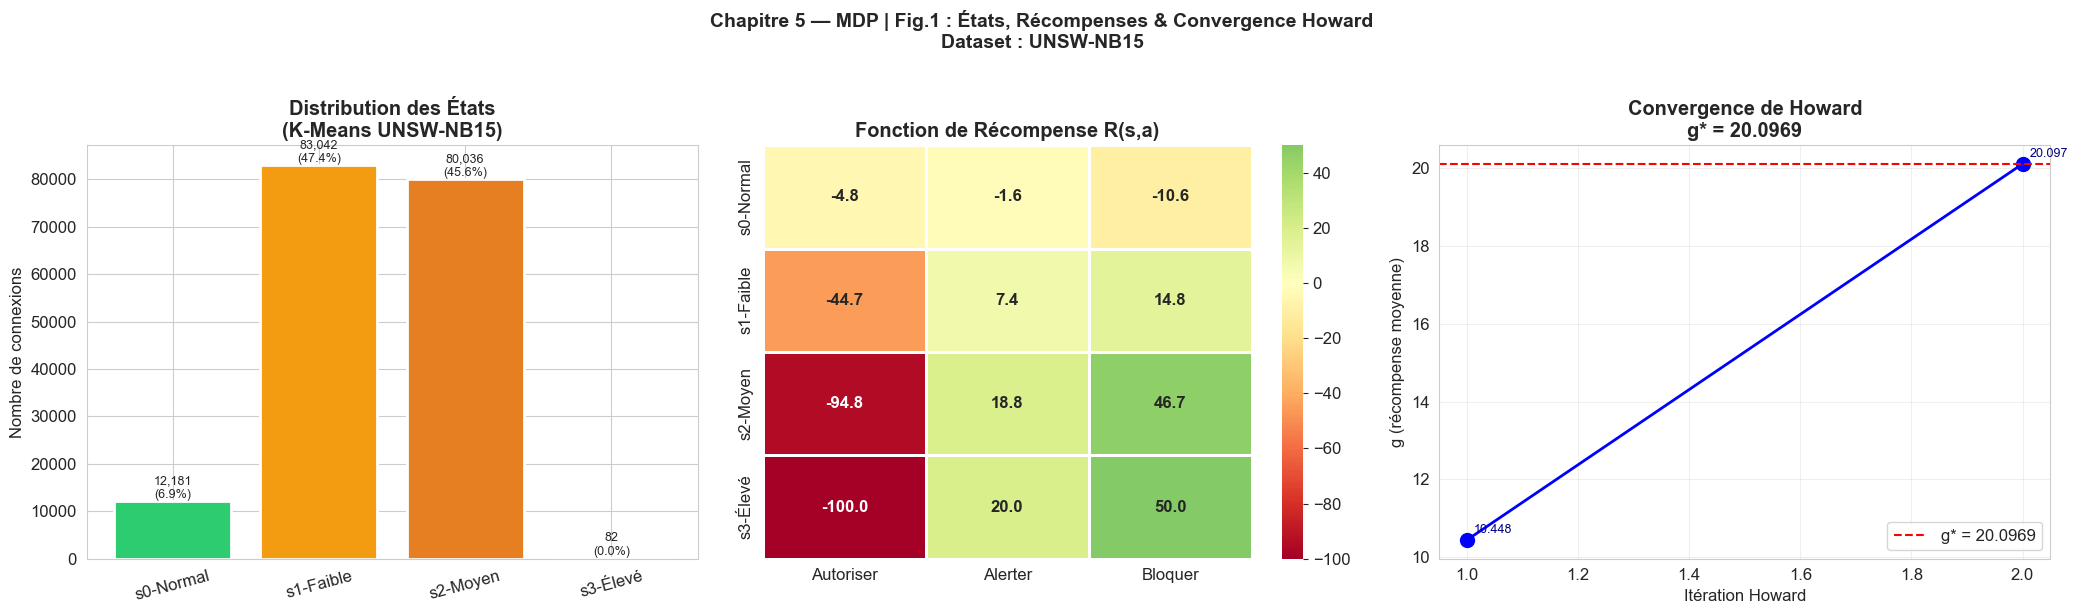

✅ Figure 1 sauvegardée


In [12]:
# ============================================================
# FIGURE 1 : États + Récompense + Howard
# ============================================================
fig1, axes = plt.subplots(1, 3, figsize=(21, 6))
fig1.suptitle('Chapitre 5 — MDP | Fig.1 : États, Récompenses & Convergence Howard\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# Distribution états (train)
counts_st = [(state_tr==s).sum() for s in range(N_STATES)]
bars = axes[0].bar([STATE_NAMES[s] for s in range(N_STATES)], counts_st,
                   color=COLORS_ST, edgecolor='white', lw=2)
for b, v in zip(bars, counts_st):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{v:,}\n({v/len(state_tr)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Distribution des États\n(K-Means UNSW-NB15)', fontweight='bold')
axes[0].set_ylabel('Nombre de connexions')
axes[0].tick_params(axis='x', rotation=15)

# Heatmap récompenses
sns.heatmap(R, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            xticklabels=[ACTION_NAMES[a] for a in range(N_ACTIONS)],
            yticklabels=[STATE_NAMES[s] for s in range(N_STATES)],
            ax=axes[1], linewidths=1, annot_kws={'size':12,'weight':'bold'})
axes[1].set_title('Fonction de Récompense R(s,a)', fontweight='bold')

# Convergence Howard
g_hist = [h['g'] for h in history_howard]
axes[2].plot(range(1,len(g_hist)+1), g_hist, 'bo-', lw=2, markersize=10)
axes[2].axhline(y=g_howard, color='red', linestyle='--', lw=1.5, label=f'g* = {g_howard:.4f}')
axes[2].set_xlabel('Itération Howard'); axes[2].set_ylabel('g (récompense moyenne)')
axes[2].set_title(f'Convergence de Howard\ng* = {g_howard:.4f}', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)
for i, g in enumerate(g_hist):
    axes[2].annotate(f'{g:.3f}', (i+1, g), textcoords='offset points',
                     xytext=(5,5), fontsize=9, color='navy')

plt.tight_layout()
plt.savefig('ch5_fig1_states_rewards.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 sauvegardée')


  ✅ Value Iteration convergée en 26 itérations (δ=5.99e-07)
  ✅ Value Iteration convergée en 77 itérations (δ=8.67e-07)
  ✅ Value Iteration convergée en 161 itérations (δ=9.59e-07)
  ✅ Value Iteration convergée en 329 itérations (δ=9.92e-07)
  ✅ Value Iteration convergée en 1675 itérations (δ=9.92e-07)


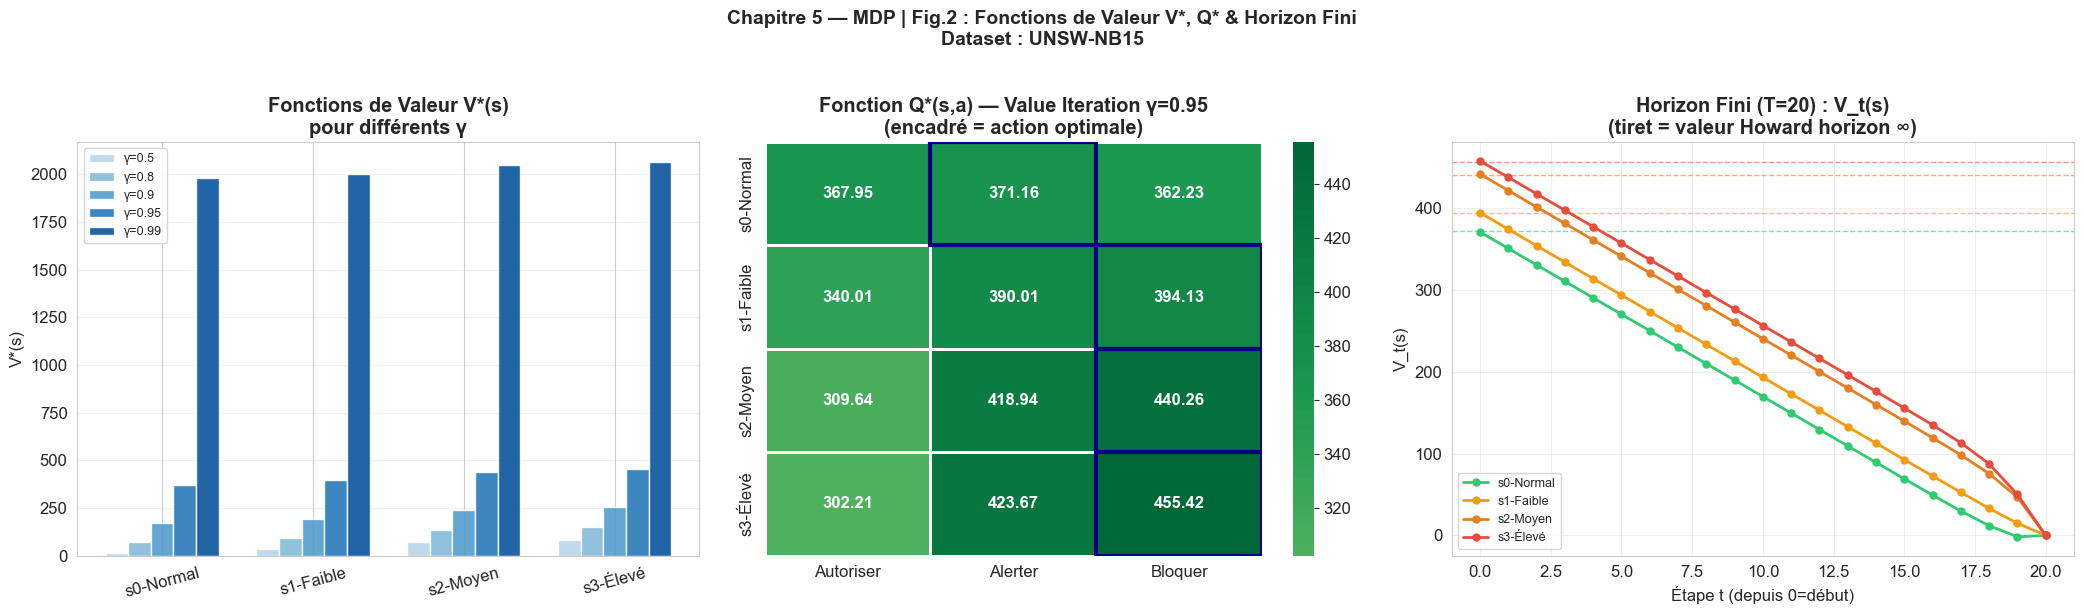

✅ Figure 2 sauvegardée


In [13]:
# ============================================================
# FIGURE 2 : Fonctions de Valeur V*(s) + Q*(s,a) + Horizon fini
# ============================================================
fig2, axes = plt.subplots(1, 3, figsize=(21, 6))
fig2.suptitle('Chapitre 5 — MDP | Fig.2 : Fonctions de Valeur V*, Q* & Horizon Fini\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# V*(s) pour différents γ
ax = axes[0]
gammas_plot = [0.5, 0.8, 0.9, 0.95, 0.99]
x = np.arange(N_STATES)
w = 0.15
cmap_g = plt.cm.Blues
for i, g in enumerate(gammas_plot):
    V_g, _, _, _, _ = value_iteration(P, R, N_STATES, N_ACTIONS, gamma=g, theta=1e-6)
    ax.bar(x + i*w, V_g, w, label=f'γ={g}', color=cmap_g(0.3 + 0.14*i), alpha=0.9)
ax.set_xticks(x + w*2)
ax.set_xticklabels([STATE_NAMES[s] for s in range(N_STATES)], rotation=15)
ax.set_ylabel('V*(s)')
ax.set_title('Fonctions de Valeur V*(s)\npour différents γ', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Heatmap Q*(s,a)
sns.heatmap(Q_vi, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=[ACTION_NAMES[a] for a in range(N_ACTIONS)],
            yticklabels=[STATE_NAMES[s] for s in range(N_STATES)],
            ax=axes[1], linewidths=1, annot_kws={'size':12,'weight':'bold'})
for s in range(N_STATES):
    axes[1].add_patch(plt.Rectangle((pi_vi[s], s), 1, 1, fill=False,
                                     edgecolor='navy', lw=3))
axes[1].set_title(f'Fonction Q*(s,a) — Value Iteration γ={GAMMA}\n(encadré = action optimale)',
                   fontweight='bold')

# Évolution V_t(s=Normal) selon l'étape de l'horizon fini
ax = axes[2]
for s in range(N_STATES):
    ax.plot(range(T_HORIZON+1), V_fh[:, s], 'o-', color=COLORS_ST[s],
            lw=2, markersize=5, label=STATE_NAMES[s])
    ax.axhline(y=V_howard_eval[s], color=COLORS_ST[s], linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel('Étape t (depuis 0=début)')
ax.set_ylabel('V_t(s)')
ax.set_title(f'Horizon Fini (T={T_HORIZON}) : V_t(s)\n(tiret = valeur Howard horizon ∞)',
              fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ch5_fig2_value_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 sauvegardée')


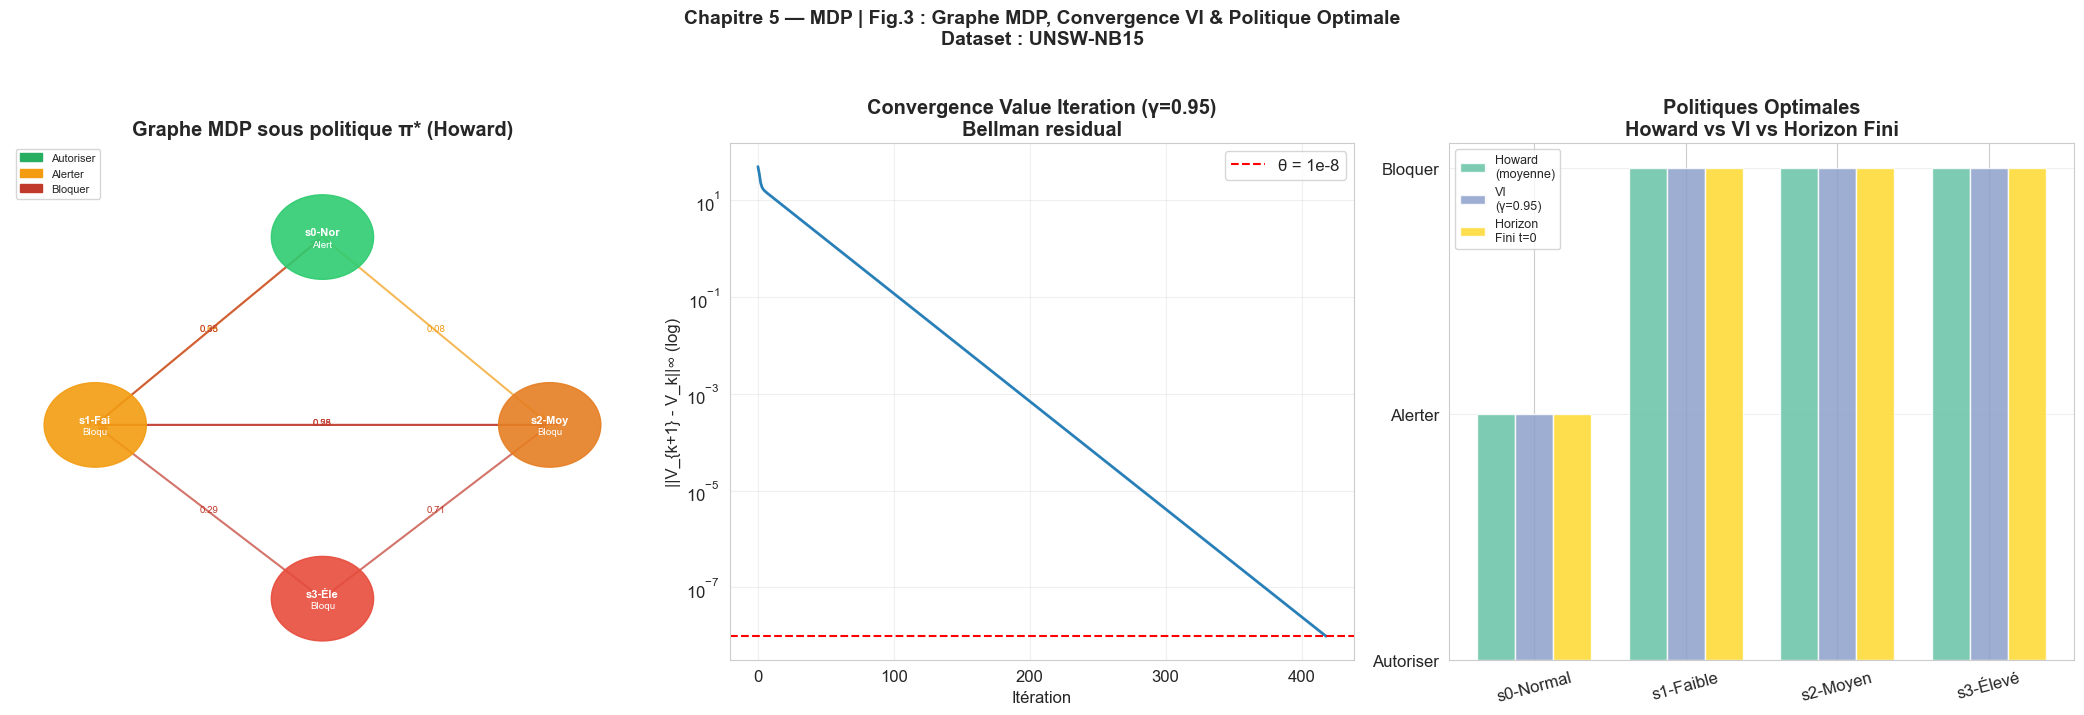

✅ Figure 3 sauvegardée


In [14]:
# ============================================================
# FIGURE 3 : Graphe du MDP + Value Iteration convergence + Politique
# ============================================================
fig3, axes = plt.subplots(1, 3, figsize=(21, 7))
fig3.suptitle('Chapitre 5 — MDP | Fig.3 : Graphe MDP, Convergence VI & Politique Optimale\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# ── Graphe du MDP (politique Howard) ──
ax = axes[0]
pos = {0:(0.5,0.85), 1:(0.1,0.45), 2:(0.9,0.45), 3:(0.5,0.08)}
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.axis('off')
for s in range(N_STATES):
    a    = pi_howard[s]
    x1,y1 = pos[s]
    for s2 in range(N_STATES):
        prob = P[a, s, s2]
        if prob > 0.04:
            x2,y2 = pos[s2]
            ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.5,
                                color=COLORS_ACT[a], alpha=0.7))
            mx,my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx, my, f'{prob:.2f}', fontsize=7,
                    ha='center', color=COLORS_ACT[a])
for s in range(N_STATES):
    x,y = pos[s]
    a   = pi_howard[s]
    circle = plt.Circle((x,y), 0.09, color=COLORS_ST[s],
                         zorder=5, alpha=0.9)
    ax.add_patch(circle)
    ax.text(x, y+0.01, STATE_NAMES[s][:6], ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=6)
    ax.text(x, y-0.015, ACTION_NAMES[a][:5], ha='center', va='center',
            fontsize=7, color='white', zorder=6)
patches = [mpatches.Patch(color=COLORS_ACT[a], label=ACTION_NAMES[a])
           for a in range(N_ACTIONS)]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_title('Graphe MDP sous politique π* (Howard)', fontweight='bold')

# ── Convergence Value Iteration ──
ax = axes[1]
ax.semilogy(delta_hist_vi, color='#2980b9', lw=2)
ax.axhline(y=1e-8, color='red', linestyle='--', label='θ = 1e-8')
ax.set_xlabel('Itération'); ax.set_ylabel('||V_{k+1} - V_k||∞ (log)')
ax.set_title(f'Convergence Value Iteration (γ={GAMMA})\nBellman residual', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Politique optimale — barres par état ──
ax = axes[2]
algos  = ['Howard\n(moyenne)', f'VI\n(γ={GAMMA})', 'Horizon\nFini t=0']
pols   = [pi_howard, pi_vi, pi_fh[0]]
x = np.arange(N_STATES); w2 = 0.25
for i, (algo, pol) in enumerate(zip(algos, pols)):
    bars2 = ax.bar(x + i*w2, pol, w2, label=algo,
                   color=plt.cm.Set2(i/3), alpha=0.85)
ax.set_xticks(x + w2)
ax.set_xticklabels([STATE_NAMES[s] for s in range(N_STATES)], rotation=15)
ax.set_yticks([0,1,2])
ax.set_yticklabels([ACTION_NAMES[a] for a in range(N_ACTIONS)])
ax.set_title('Politiques Optimales\nHoward vs VI vs Horizon Fini', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ch5_fig3_mdp_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 sauvegardée')


In [15]:
# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================
print('\n' + '='*75)
print('  RÉCAPITULATIF — CHAPITRE 5 : Processus de Décision Markovien')
print('='*75)

print(f'\n  [1] Espace du MDP')
print(f'      États   S = {N_STATES}  (construits par K-Means sur UNSW-NB15)')
print(f'      Actions A = {N_ACTIONS}  (Autoriser / Alerter / Bloquer)')

print(f'\n  [2] Algorithme de Howard (récompense moyenne, horizon infini)')
print(f'      g* = {g_howard:.4f}')
for s in range(N_STATES):
    print(f'      π*({STATE_NAMES[s]:15s}) = {ACTION_NAMES[pi_howard[s]]}')

print(f'\n  [3] Value Iteration — coûts actualisés (γ = {GAMMA})')
for s in range(N_STATES):
    print(f'      V*({STATE_NAMES[s]:15s}) = {V_vi[s]:8.4f}  |  π* = {ACTION_NAMES[pi_vi[s]]}')

print(f'\n  [4] Horizon fini (T = {T_HORIZON}) — Backward Induction')
print(f'      Politique non-stationnaire : π*(s,t) dépend du temps restant')
print(f'      Converge vers la politique stationnaire pour les dernières étapes')

print(f'\n  [5] Évaluation sur UNSW-NB15 (test)')
print(f'      Décisions correctes de π* = {correct:.1%}')

print('\n✅ Chapitre 5 complet — Howard · Value Iteration · Horizons · V(s) · Q(s,a)')



  RÉCAPITULATIF — CHAPITRE 5 : Processus de Décision Markovien

  [1] Espace du MDP
      États   S = 4  (construits par K-Means sur UNSW-NB15)
      Actions A = 3  (Autoriser / Alerter / Bloquer)

  [2] Algorithme de Howard (récompense moyenne, horizon infini)
      g* = 20.0969
      π*(s0-Normal      ) = Alerter
      π*(s1-Faible      ) = Bloquer
      π*(s2-Moyen       ) = Bloquer
      π*(s3-Élevé       ) = Bloquer

  [3] Value Iteration — coûts actualisés (γ = 0.95)
      V*(s0-Normal      ) = 371.1579  |  π* = Alerter
      V*(s1-Faible      ) = 394.1328  |  π* = Bloquer
      V*(s2-Moyen       ) = 440.2582  |  π* = Bloquer
      V*(s3-Élevé       ) = 455.4202  |  π* = Bloquer

  [4] Horizon fini (T = 20) — Backward Induction
      Politique non-stationnaire : π*(s,t) dépend du temps restant
      Converge vers la politique stationnaire pour les dernières étapes

  [5] Évaluation sur UNSW-NB15 (test)
      Décisions correctes de π* = 55.1%

✅ Chapitre 5 complet — Howard · Valu